In [3]:
import numpy as np
import pandas as pd
df = pd.read_csv("../data/final_training_dataset.csv")   
mean_distance = np.mean(df["voltage_gap"])
std_distance = np.std(df["voltage_gap"])
import matplotlib.pyplot as plt
import seaborn as sns
import os
from concurrent.futures import ThreadPoolExecutor

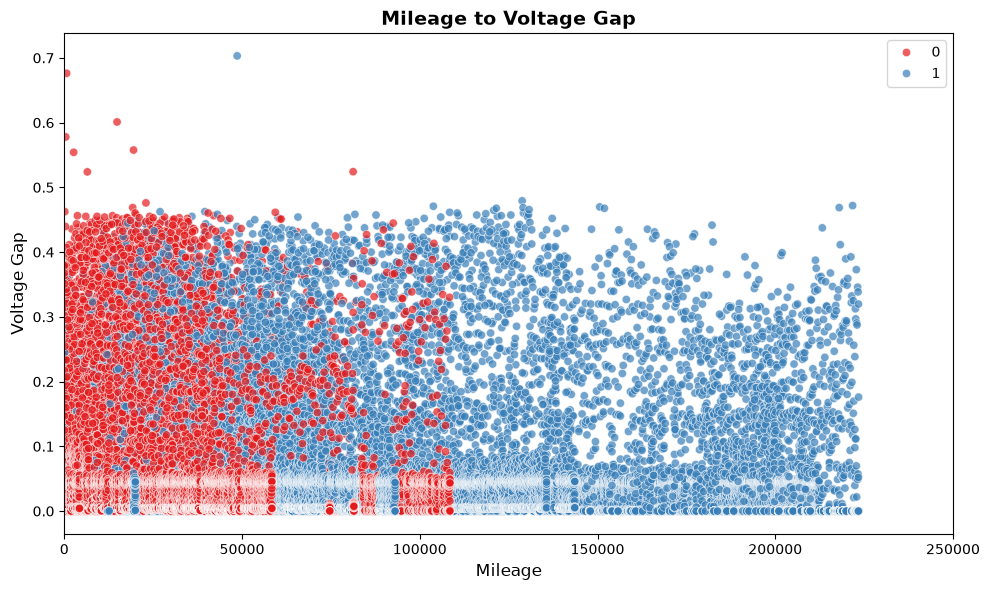

In [4]:
plt.figure(figsize=(10, 6))

# Plot only the random subset
sns.scatterplot(data=df, x='mileage', y='voltage_gap', hue='label', palette='Set1', alpha=0.7)


plt.title("Mileage to Voltage Gap", fontsize=14, fontweight='bold')
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Voltage Gap", fontsize=12)
plt.legend()

# Zoom in on the x-axis up to 250,000 and y-axis up to 100
plt.xlim(0, 250000)  # You can also write this as 0.25e6

plt.tight_layout()
plt.show()

In [5]:
# From this Milage to voltage gap, we can see that the cars with broken cells are mosstly in the upper milage range, and the voltage gap does now show significant correlation with the milage.
# However i could also say as milage increase, the higher the voltage gap, the more likely the car has broken cells.

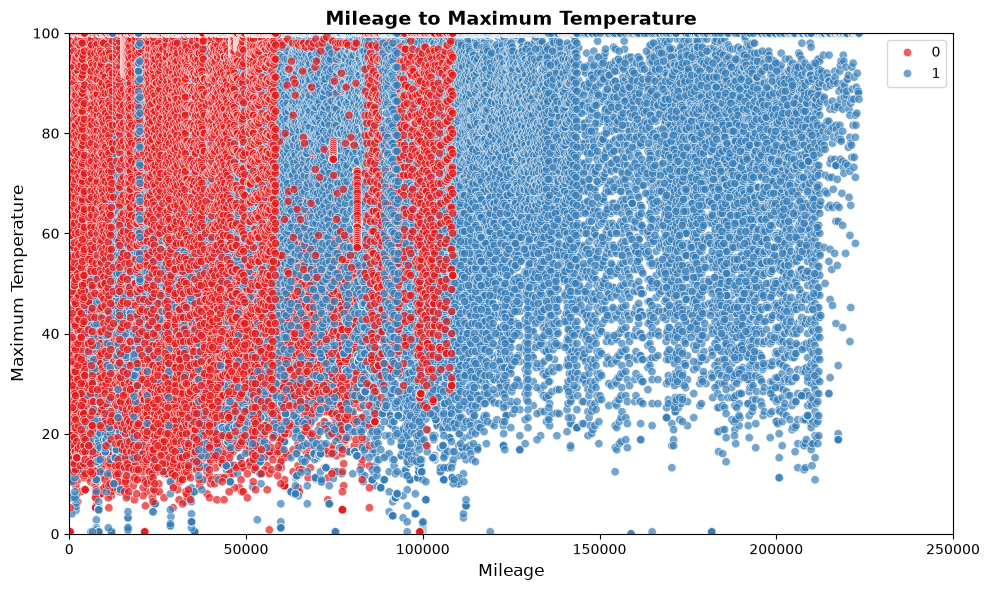

In [6]:
plt.figure(figsize=(10, 6))

# Plot only the random subset
sns.scatterplot(data=df, x='mileage', y='max_temp', hue='label', palette='Set1', alpha=0.7)


plt.title("Mileage to Maximum Temperature", fontsize=14, fontweight='bold')
plt.xlabel("Mileage", fontsize=12)
plt.ylabel("Maximum Temperature", fontsize=12)
plt.legend()

# Zoom in on the x-axis up to 250,000 and y-axis up to 100
plt.xlim(0, 250000)  
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [7]:
# most of the broken cars are in the upper milag ranke (110,000 + ) 
# broken cell experience wider range of max temp, but not all cars with high max temp have broken cells.

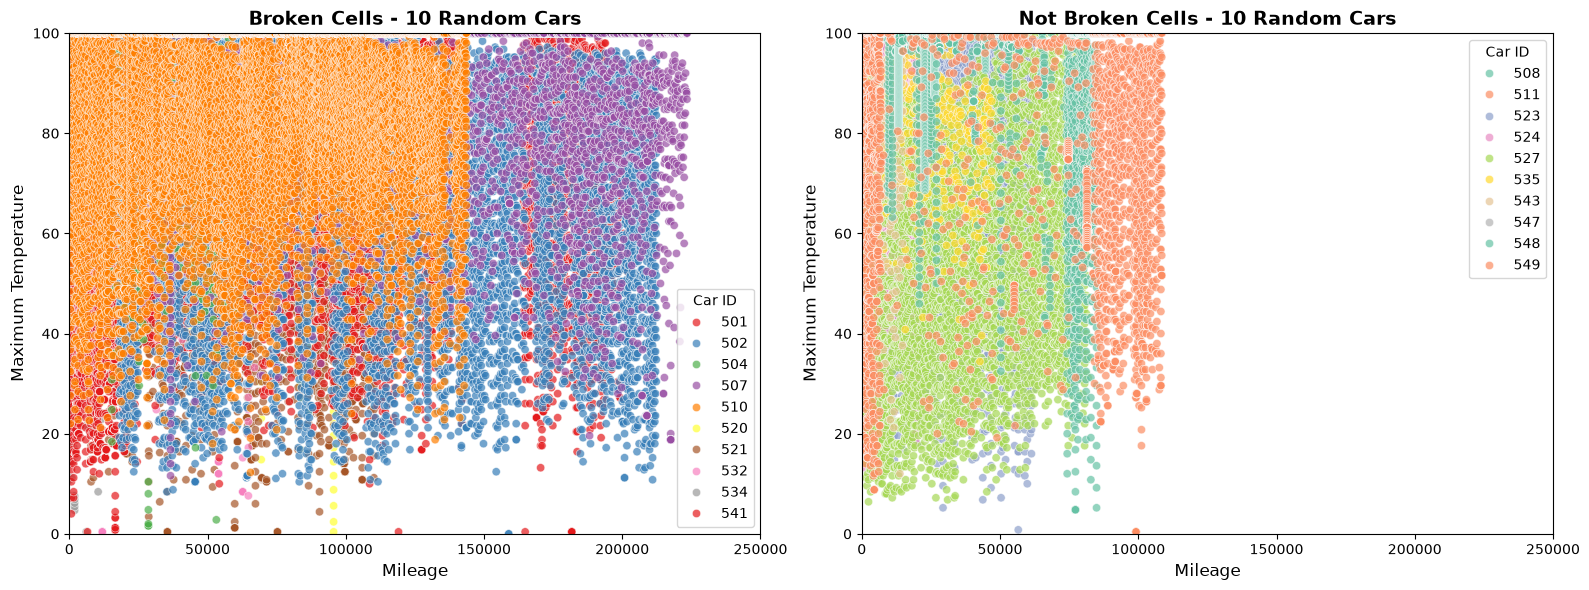

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_ones = df[df['label'] == 1]
df_zeros = df[df['label'] == 0]


unique_broken = df_ones['car'].unique()
random_10_broken = np.random.choice(unique_broken, size=10, replace=False)
df_broken_subset = df_ones[df_ones['car'].isin(random_10_broken)]


unique_not_broken = df_zeros['car'].unique()
random_10_not_broken = np.random.choice(unique_not_broken, size=10, replace=False)
df_not_broken_subset = df_zeros[df_zeros['car'].isin(random_10_not_broken)]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: Broken Cars (Left) ---
sns.scatterplot(
    data=df_broken_subset, x='mileage', y='max_temp', 
    hue='car', palette='Set1', alpha=0.7, ax=axes[0]
)
axes[0].set_title("Broken Cells - 10 Random Cars", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Mileage", fontsize=12)
axes[0].set_ylabel("Maximum Temperature", fontsize=12)
axes[0].set_xlim(0, 250000)
axes[0].set_ylim(0, 100)
axes[0].legend(title="Car ID")

# --- GRAPH 2: Not Broken Cars (Right) ---
sns.scatterplot(
    data=df_not_broken_subset, x='mileage', y='max_temp', 
    hue='car', palette='Set2', alpha=0.7, ax=axes[1]
)
axes[1].set_title("Not Broken Cells - 10 Random Cars", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Mileage", fontsize=12)
axes[1].set_ylabel("Maximum Temperature", fontsize=12)
axes[1].set_xlim(0, 250000)
axes[1].set_ylim(0, 100)
axes[1].legend(title="Car ID")

# Adjust layout and display
plt.tight_layout()
plt.show()

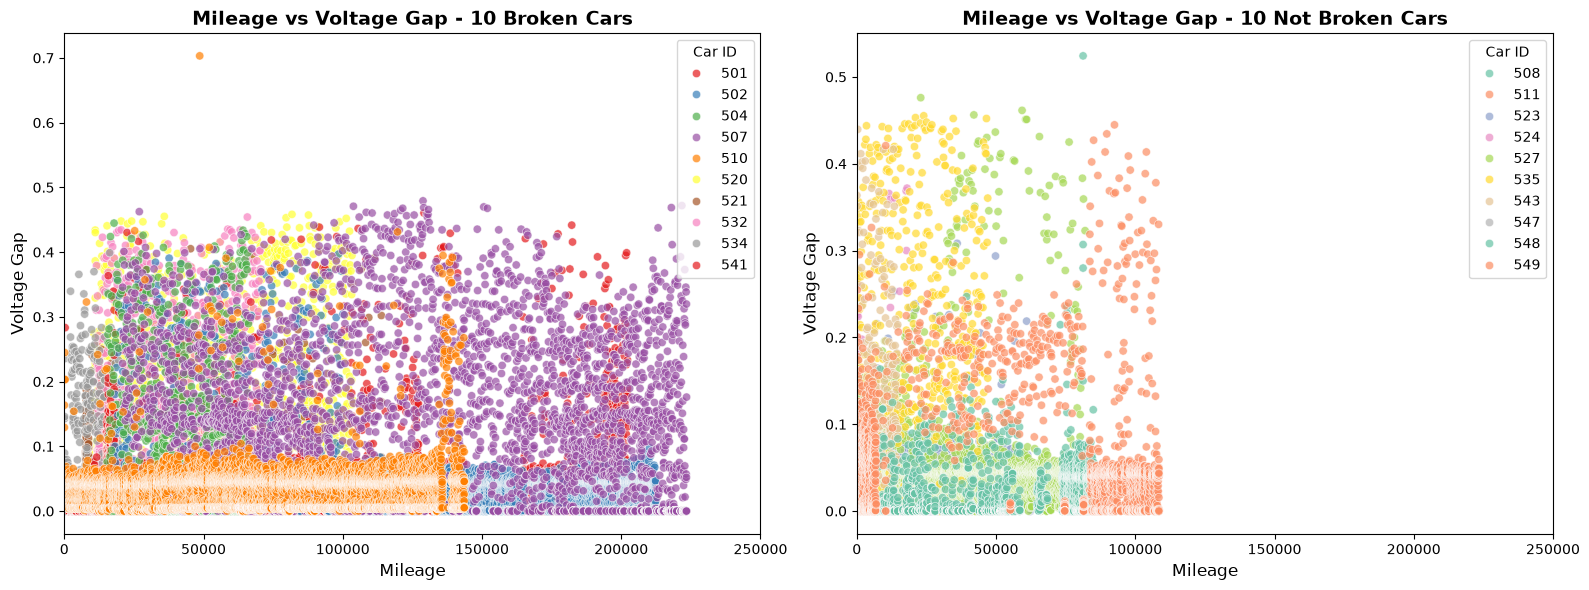

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    data=df_broken_subset, x='mileage', y='voltage_gap', 
    hue='car', palette='Set1', alpha=0.7, ax=axes[0]
)
axes[0].set_title("Mileage vs Voltage Gap - 10 Broken Cars", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Mileage", fontsize=12)
axes[0].set_ylabel("Voltage Gap", fontsize=12)
axes[0].set_xlim(0, 250000)
axes[0].legend(title="Car ID")

sns.scatterplot(
    data=df_not_broken_subset, x='mileage', y='voltage_gap', 
    hue='car', palette='Set2', alpha=0.7, ax=axes[1]
)
axes[1].set_title("Mileage vs Voltage Gap - 10 Not Broken Cars", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Mileage", fontsize=12)
axes[1].set_ylabel("Voltage Gap", fontsize=12)
axes[1].set_xlim(0, 250000)
axes[1].legend(title="Car ID")

plt.tight_layout()
plt.show()

In [10]:
# From the milage vs voltage gap graph, we can see that the broken cars have a smaller range of voltage gap
# We can see that the non-broken cars somehow have a wider range of voltage gap, but the broken cars have a smaller range of voltage gap. 
# This could be due to the fact that the broken cars are mostly in the upper milage range, and the voltage gap does not show significant correlation with the milage. 

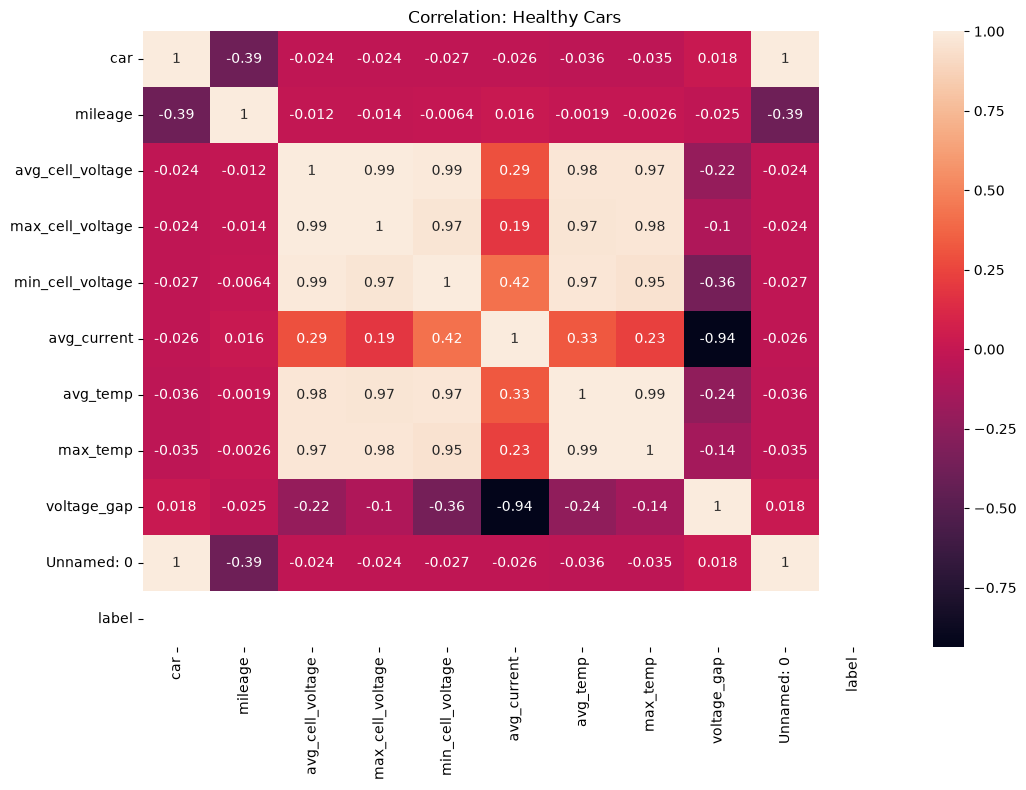

In [11]:
plt.figure(figsize=(12, 8))
# Correlation for Healthy Cars
corr_healthy = df[df['label'] == 0].corr()
sns.heatmap(corr_healthy, annot=True)
plt.title("Correlation: Healthy Cars")
plt.show()

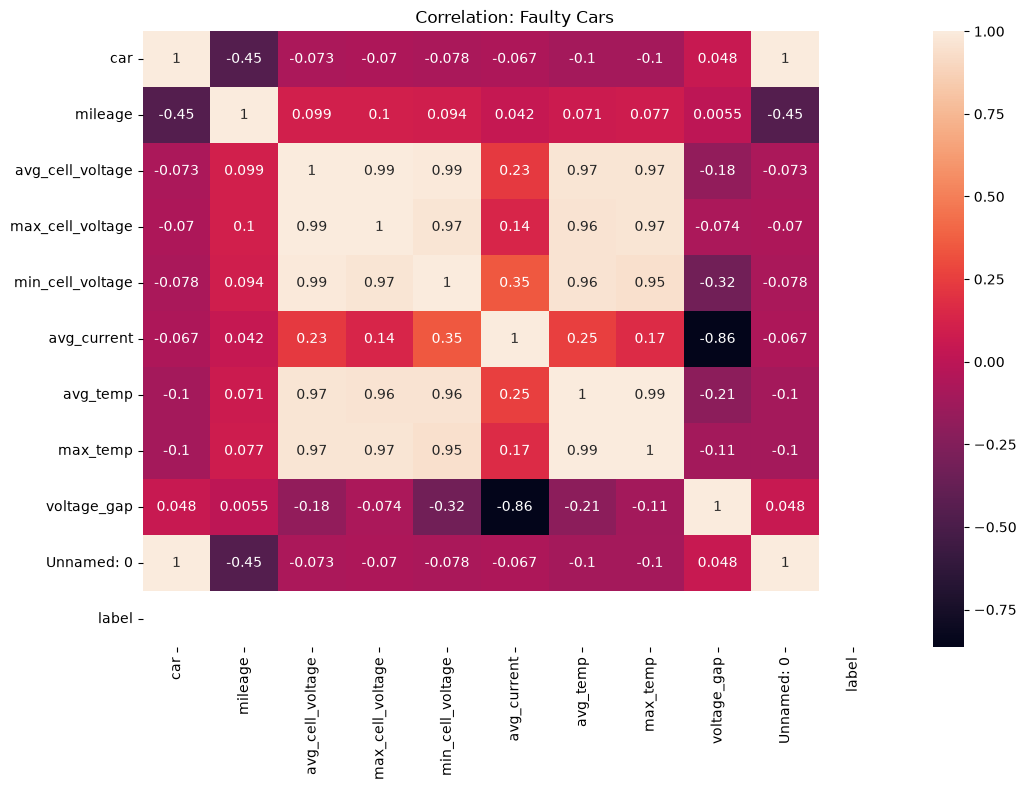

In [12]:
# Correlation for Faulty Cars
plt.figure(figsize=(12, 8))
corr_faulty = df[df['label'] == 1].corr()
sns.heatmap(corr_faulty, annot=True)
plt.title("Correlation: Faulty Cars")
plt.show()

In [13]:
# correlation between voltage_gap and min_cell_voltage is -0.36 for healthy cars and -0.32 for faulty cars.
# faulty cars, a widening voltage gap is slightly less tied to the absolute minimum cell voltage,


# Voltage Gap & Average Current 
# correlation is -0.94 for healthy cars and -0.86 for faulty cars.
# as current increases, the voltage gap widens, and this is more pronounced for healthy cars than for faulty cars.
# This means faulty cars have a less predictable voltage gap under load (spiking)


# Mileage & Max Temp 
# Correlation is -0.0026 for healthy cars and 0.077 for faulty cars. 
# For healthy cars, there is no correlation between mileage and max temp, but for faulty cars, there is a slight positive correlation.(sign of thermal degradation over the life of the battery)


C:\Users\Trevor\AppData\Local\Temp\ipykernel_6788\1121521457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='voltage_gap', ax=axes[0], palette="Set2")
C:\Users\Trevor\AppData\Local\Temp\ipykernel_6788\1121521457.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='max_temp', ax=axes[1], palette="Set2")


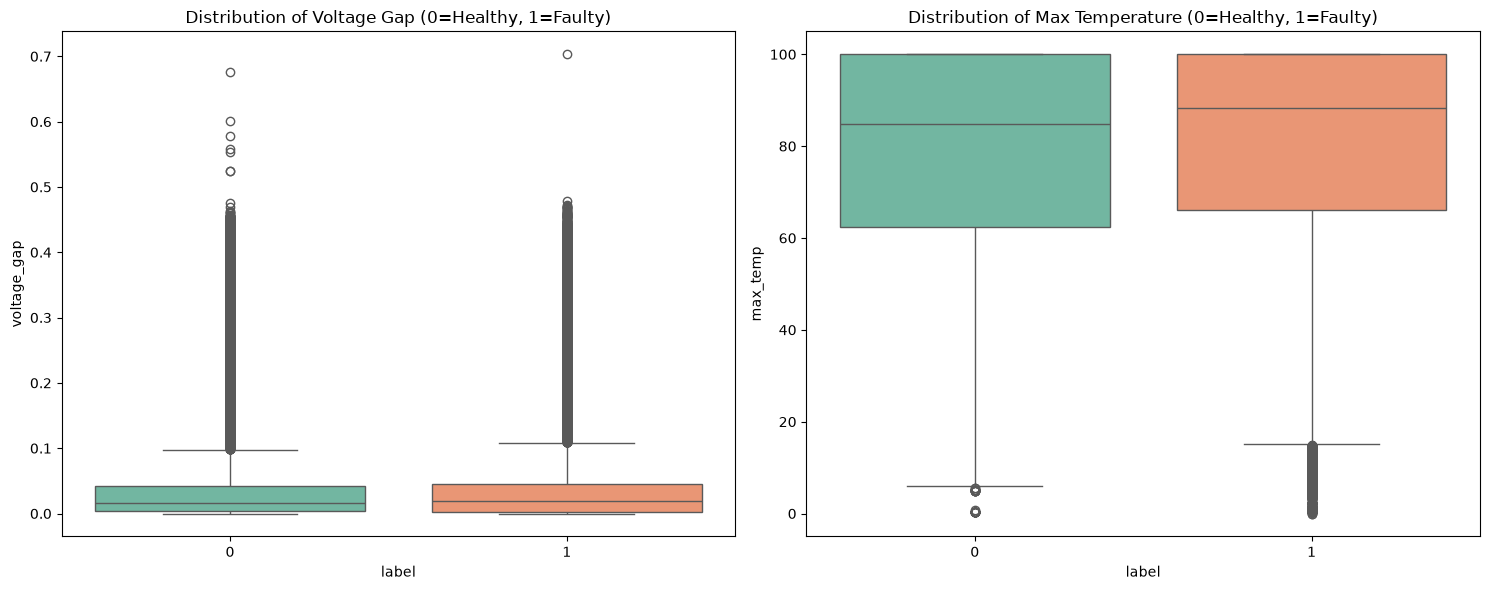

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot for Voltage Gap
sns.boxplot(data=df, x='label', y='voltage_gap', ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of Voltage Gap (0=Healthy, 1=Faulty)")

# Boxplot for Max Temp
sns.boxplot(data=df, x='label', y='max_temp', ax=axes[1], palette="Set2")
axes[1].set_title("Distribution of Max Temperature (0=Healthy, 1=Faulty)")

plt.tight_layout()
plt.show()

In [15]:
# For the distribution of voltage gap I can see that broken cars have a higher 75% than healthy cars, and the median is also higher for broken cars.
# This means broken cars have a persistent baseline of the voltage gap, which is a sign of cell degradation.

#For the distribution of max temp, I can see that the distribution for broken car is more higher than healthy cars, and the median is also higher for broken cars. 
# the mean and the botton of the boxplot is also higher than healthy cars which means faulty cars consistently run hotter on average

In [16]:
import numpy as np

all_cars = df['car'].unique()

np.random.seed(42) # Set a seed
train_cars = np.random.choice(all_cars, size=40, replace=False)

test_cars = [car for car in all_cars if car not in train_cars]

# 4. Create the final DataFrames
df_train = df[df['car'].isin(train_cars)]
df_test = df[df['car'].isin(test_cars)]

print(f"Training on {len(train_cars)} cars (Rows: {len(df_train)})")
print(f"Testing on {len(test_cars)} cars (Rows: {len(df_test)})")

Training on 40 cars (Rows: 163064)
Testing on 9 cars (Rows: 13263)


In [24]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Features (X) and Labels (y)
# We drop 'label', 'car', and 'Unnamed: 0' (if it exists) so the AI doesn't cheat!
drop_cols = ['label', 'car']
if 'Unnamed: 0' in df_train.columns:
    drop_cols.append('Unnamed: 0')

X_train = df_train.drop(columns=drop_cols)
y_train = df_train['label']

X_test = df_test.drop(columns=drop_cols)
y_test = df_test['label']

# 2. Initialize and Train the Model
print("Training XGBoost Model...")
model = xgb.XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# 3. Test the Model on the 9 UNSEEN cars
predictions = model.predict(X_test)

# 4. Show the Results!
accuracy = accuracy_score(y_test, predictions)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_test, predictions))

Training XGBoost Model...
✅ Test Accuracy: 70.53%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80     10610
           1       0.34      0.53      0.42      2653

    accuracy                           0.71     13263
   macro avg       0.60      0.64      0.61     13263
weighted avg       0.76      0.71      0.73     13263



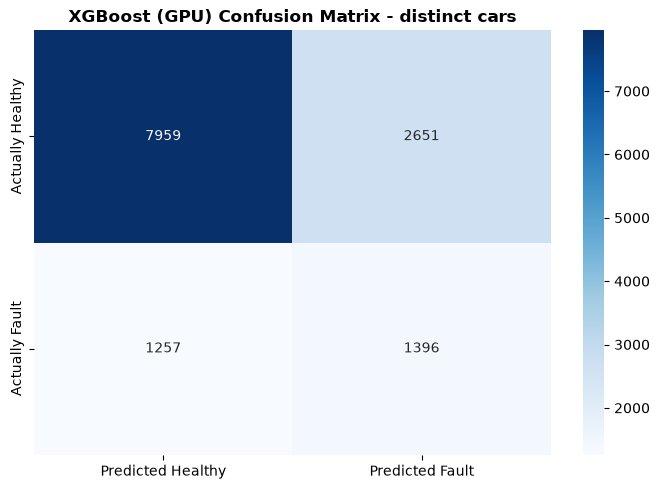

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Fault'], 
            yticklabels=['Actually Healthy', 'Actually Fault'])
plt.title("XGBoost (GPU) Confusion Matrix - distinct cars", fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Separate Features (X) and Labels (y)
# We drop 'label', 'car', and 'Unnamed: 0' (if it exists) so the AI doesn't cheat!
drop_cols = ['label', 'car']
if 'Unnamed: 0' in df_train.columns:
    drop_cols.append('Unnamed: 0')

X_train = df_train.drop(columns=drop_cols)
y_train = df_train['label']

X_test = df_test.drop(columns=drop_cols)
y_test = df_test['label']

# 1. Calculate the Imbalance Ratio
# This tells the model how many healthy (0) cars there are for every faulty (1) car
num_healthy = np.sum(y_train == 0)
num_faulty = np.sum(y_train == 1)
imbalance_ratio = num_healthy / num_faulty

print(f"📊 Dataset Balance: {num_healthy} healthy, {num_faulty} faulty.")
print(f"⚖️ Setting scale_pos_weight to: {imbalance_ratio:.2f}")

# 2. Initialize and Train the Model with scale_pos_weight
print("Training XGBoost Model...")
model = xgb.XGBClassifier(
    random_state=42, 
    scale_pos_weight=imbalance_ratio  # <--- This is the secret sauce!
)
model.fit(X_train, y_train)

# 3. Test the Model on the UNSEEN cars
predictions = model.predict(X_test)

# 4. Show the Results!
accuracy = accuracy_score(y_test, predictions)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_test, predictions))


📊 Dataset Balance: 66666 healthy, 96398 faulty.
⚖️ Setting scale_pos_weight to: 0.69
Training XGBoost Model...
✅ Test Accuracy: 72.00%

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     10610
           1       0.36      0.50      0.42      2653

    accuracy                           0.72     13263
   macro avg       0.61      0.64      0.62     13263
weighted avg       0.76      0.72      0.74     13263



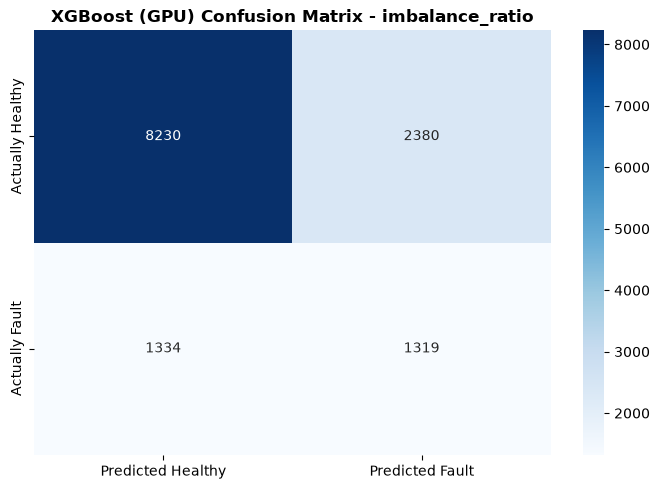

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Fault'], 
            yticklabels=['Actually Healthy', 'Actually Fault'])
plt.title("XGBoost (GPU) Confusion Matrix - imbalance_ratio", fontweight='bold')
plt.tight_layout()
plt.show()